
# Theory/Scientific Track Starter Notebook

This starter notebook is for the Bitcamp 2026 theory/scientific track challenge:
**map the phase diagram of the 1D ANNNI model and study how gate noise distorts it**.

What this notebook does:
- builds the ANNNI Hamiltonian in the repo's `Z/Z/X` convention,
- uses exact diagonalization as a trustworthy small-system baseline,
- introduces finite-size observables that are more useful than raw magnetization,
- demonstrates one small observable sweep,
- demonstrates the depolarizing-after-CNOT noise convention.

What it does **not** do:
- ship a full QCNN or autoencoder,
- generate the final clean/noisy phase diagrams,
- provide a reusable phase classifier.

Reference note: the PennyLane ANNNI demo uses an equivalent open-chain `X/X/Z` convention, while this challenge notebook uses periodic boundaries and a `Z/Z/X` convention. Treat the analytical phase lines as qualitative overlays for a finite-size benchmark, not exact finite-`N` truth.

The worked examples below use `N=6` so the notebook stays fast to rerun. Your actual submission should still target `N >= 8`.


In [1]:

import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-scientific-track")

import numpy as np
import matplotlib.pyplot as plt

from starter_kit import (
    animate_linecut,
    build_annni_hamiltonian,
    exact_ground_state,
    plot_coupling_graph,
    simple_noisy_energy,
)

demo_n = 6



## 1. Hamiltonian and Coupling Pattern

We use the periodic-boundary ANNNI Hamiltonian

$$H = -\sum_i Z_i Z_{i+1} + \kappa \sum_i Z_i Z_{i+2} - h \sum_i X_i.$$

The solid links below are nearest-neighbor couplings, and the dashed links are next-nearest-neighbor frustration terms.


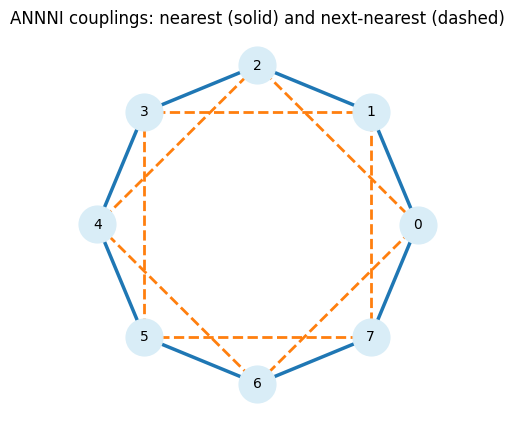

In [2]:

fig, ax = plot_coupling_graph(n_qubits=8, periodic=True)
plt.show()



## 2. Exact Diagonalization Baseline

For the worked example `N=6`, exact diagonalization is still cheap, so it makes a good organizer-provided reference.
The key lesson is that finite-size ground states often preserve the global symmetry, so `⟨Z_i⟩` stays near zero even in ordered phases.
Correlation observables are more useful.


In [3]:

sample_points = [
    (0.20, 0.20),
    (0.80, 0.20),
    (0.20, 1.60),
    (0.80, 1.00),
]

for kappa, h in sample_points:
    result = exact_ground_state(n_qubits=demo_n, kappa=kappa, h=h, periodic=True)
    summary = result["summary"]
    print(f"(kappa={kappa:.2f}, h={h:.2f})")
    print(f"  ground energy: {result['ground_energy']:.6f}")
    print(f"  gap:           {result['energy_gap']:.6f}")
    print(f"  z_abs_mean:    {summary['z_abs_mean']:.6f}")
    print(f"  x_mean:        {summary['x_mean']:.6f}")
    print(f"  zz_nearest:    {summary['zz_nearest_mean']:.6f}")
    print(f"  zz_next:       {summary['zz_next_nearest_mean']:.6f}")
    print()


(kappa=0.20, h=0.20)
  ground energy: -4.875718
  gap:           0.000165
  z_abs_mean:    0.000000
  x_mean:        0.127559
  zz_nearest:    0.983770
  zz_next:       0.983312

(kappa=0.80, h=0.20)
  ground energy: -4.214667
  gap:           0.088305
  z_abs_mean:    0.000000
  x_mean:        0.552406
  zz_nearest:    0.329629
  zz_next:       -0.327918

(kappa=0.20, h=1.60)
  ground energy: -10.436503
  gap:           1.784767
  z_abs_mean:    0.000000
  x_mean:        0.924474
  zz_nearest:    0.270720
  zz_next:       0.052309

(kappa=0.80, h=1.00)
  ground energy: -7.574721
  gap:           0.864237
  z_abs_mean:    0.000000
  x_mean:        0.821692
  zz_nearest:    0.257778
  zz_next:       -0.228729




## 3. Small Observable Sweep

This section shows how to build your own scan loop without shipping a classifier. We only sweep three `h` values and track two observables.


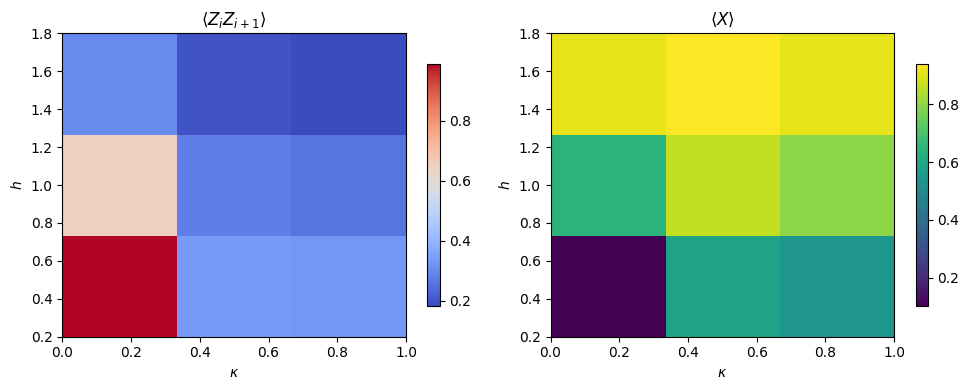

In [4]:

kappas = np.linspace(0.0, 1.0, 3)
hs = np.array([0.2, 1.0, 1.8])
zz1 = np.zeros((len(hs), len(kappas)))
xmag = np.zeros((len(hs), len(kappas)))

for row, h in enumerate(hs):
    for col, kappa in enumerate(kappas):
        result = exact_ground_state(n_qubits=demo_n, kappa=float(kappa), h=float(h), periodic=True)
        zz1[row, col] = result["summary"]["zz_nearest_mean"]
        xmag[row, col] = result["summary"]["x_mean"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, values, title, cmap in [
    (axes[0], zz1, r"$\langle Z_i Z_{i+1} \rangle$", "coolwarm"),
    (axes[1], xmag, r"$\langle X \rangle$", "viridis"),
]:
    image = ax.imshow(
        values,
        origin="lower",
        aspect="auto",
        extent=[kappas.min(), kappas.max(), hs.min(), hs.max()],
        cmap=cmap,
    )
    ax.set_xlabel(r"$\kappa$")
    ax.set_ylabel(r"$h$")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()



## 4. Animation: One Observable Along a Line Cut

The animation below sweeps `h` and shows how the nearest-neighbor correlation changes with `\kappa`.
This is a compact teaching visualization, not a full phase-classification pipeline.


In [5]:

animate_linecut(
    kappas,
    hs,
    zz1,
    ylabel=r"$\langle Z_i Z_{i+1} \rangle$",
    title="Nearest-neighbor correlation",
)



## 5. Noise Convention Demo

The theory challenge inherits the PennyLane noisy-Heisenberg convention: apply `qml.DepolarizingChannel(p)` after every CNOT, on the CNOT target.

The function below is **not** a full ANNNI solver. It is just a tiny noisy ansatz demo that lets you see how circuit energy degrades as `p` increases.


p=0.00 -> noisy ansatz energy -2.156961
p=0.01 -> noisy ansatz energy -2.010068
p=0.03 -> noisy ansatz energy -1.740792
p=0.05 -> noisy ansatz energy -1.501773


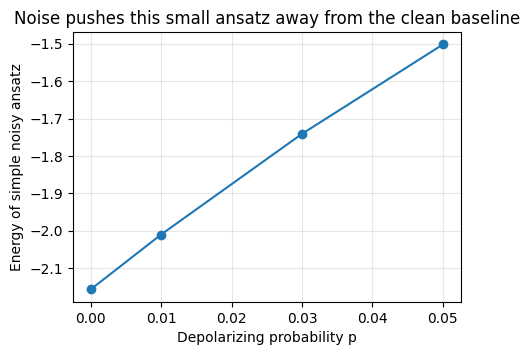

In [6]:

noise_levels = [0.0, 0.01, 0.03, 0.05]
energies = [simple_noisy_energy(4, kappa=0.4, h=0.7, theta=0.3, p=p, layers=2) for p in noise_levels]

for p, energy in zip(noise_levels, energies):
    print(f"p={p:0.2f} -> noisy ansatz energy {energy:0.6f}")

plt.figure(figsize=(5, 3.5))
plt.plot(noise_levels, energies, marker="o")
plt.xlabel("Depolarizing probability p")
plt.ylabel("Energy of simple noisy ansatz")
plt.title("Noise pushes this small ansatz away from the clean baseline")
plt.grid(alpha=0.3)
plt.show()



## 6. Suggested Next Steps for Teams

A strong submission should go beyond this notebook. Reasonable next directions include:
- write your own scan loop for the full parameter grid,
- choose or design your own phase-identification strategy,
- compare exact diagonalization against VQE or learned models,
- build clean and noisy phase diagrams at a finer grid,
- quantify phase-boundary motion as a function of noise.


In [7]:

# Team workspace
# 1. Choose your main phase-detection strategy.
# 2. Build clean and noisy scans at the grid resolution you want.
# 3. Quantify how the phase boundaries move.
# 4. Save the final plots for p=0.00, p=0.01, and p=0.05.



## References

- PennyLane demo: `tutorial_annni`
- PennyLane challenge: `A Noisy Heisenberg Model`
- PennyLane demo: `How to Build Spin Hamiltonians`
- PennyLane demo: `Seeing Quantum Phase Transitions`
- Kiss/Monaco et al., *Phys. Rev. B* 107, L081105 (2023)
- Cea et al., arXiv:2402.11022 (2024)
